<목표>

- 데이터 특성을 파악하고 시각화한다
- 비즈니스 가설을 통계로 검정한다
- 회귀분석으로 예측 모델을 만든다
- 결과를 경영진에게 설득력 있게 보고한다

1. 기술통계 기초 - 평균, 분산, 분포, 시각화
2. 추론통계 기초 - t-test, 카이제곱, A/B 테스트
3. 회귀분석 응용 - 실제 비즈니스 예시

##### 현대 비즈니스의 연실

- 데이터 폭증 : 매일 2.5조 바이트 데이터 생성
- 경쟁 심화 : 데이터 활용 능력이 생존 결정
- 의사결정의 과학화 : 직관 기반 결정에서 데이터 기반 결정으로


##### 통계학이 해결하는 문제들
- 불확실성 속에서도 합리적 의사결정을 할 수 있다
- 복잡한 현상에서 의미있는 패턴을 발견할 수 있다
- 미래 예측 및 리스트 관리가 가능하다
- 고객 이해와 맞춤형 서비스가 가능해진다

##### 기술통계
- 목적 : 데이터 요약 및 설명
- 방법 : 평균, 분산, 그래프
- 질문 : 무엇이 일어났는가?
- 예시 : 지난달 평균 매출


##### 추론통계
- 목적 : 표본을 통한 모집단 추론
- 방법 : 가설검정, 신뢰구간
- 질문 : 왜? 앞으로는?
- 예시 : 신제품이 매출을 증가시킬까?

In [1]:
# 기술통계
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
import random
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaYu Sans'
plt.rcParams['axes.unicode_minus'] = False

# 시각화 스타일 설정
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
np.random.seed(42)

n_customers = 1000
customer_data = pd.DataFrame({
    'customer_id' : range(1, n_customers + 1),
    'age' : np.random.randint(18, 70, n_customers),
    'gender' : np.random.choice(['M', 'F'], n_customers),
    'purchase_amount': np.random.exponential(100, n_customers),
    'purchase_count': np.random.poisson(5, n_customers),
    'satisfaction_score': np.random.normal(7, 1.5, n_customers),
    'member_type': np.random.choice(['Bronze', 'Silver', 'Gold'], n_customers, p=[0.6, 0.3, 0.1])
})

# 만족도 점수 1-10 제한
customer_data['satisfaction_score'] = customer_data['satisfaction_score'].clip(1, 10)

# csv 파일 저장
csv_path = "customer_data.csv"
customer_data.to_csv(csv_path, index=False, encoding='utf-8')

In [3]:
# csv 파일 읽기
csv_path = "customer_data.csv"
df = pd.read_csv(csv_path)

# 데이터 요약 및 분석 (기술통계)
print("=== 데이터 정보 .info() ===")
df.info()

print("\n=== 기술 통계량 .describe() ===")
print(df.describe())

print("\n=== 범주형 변수 요약 ===")
print(df.describe(include='object'))

=== 데이터 정보 .info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         1000 non-null   int64  
 1   age                 1000 non-null   int64  
 2   gender              1000 non-null   object 
 3   purchase_amount     1000 non-null   float64
 4   purchase_count      1000 non-null   int64  
 5   satisfaction_score  1000 non-null   float64
 6   member_type         1000 non-null   object 
dtypes: float64(2), int64(3), object(2)
memory usage: 54.8+ KB

=== 기술 통계량 .describe() ===
       customer_id         age  purchase_amount  purchase_count  \
count  1000.000000  1000.00000      1000.000000     1000.000000   
mean    500.500000    43.81900       101.733244        4.937000   
std     288.819436    14.99103       101.770670        2.106055   
min       1.000000    18.00000         0.322345        0.000000   
25%  

#### 추론통계 (모집단과 표본)

##### 모집단 (Population)
- 정의 : 관심있는 전체 집합
- 특성 : 모수(paramter) 로 표현
- 예시 : 모평균, 모분산
- 현실 : 전수조사는 어렵다

##### 표본 (Sample)
- 정의 : 모집단의 일부
- 특성 : 통계량(statistic)으로 표현
- 예시 : 표본평균, 표본분산
- 목표 : 모집단을 대표


##### 표본 정보를 통해 모집단의 특성을 추론

In [4]:
# 표본 샘플링
population = list(range(1, 101))            # 1~100
sample_size = 10

# 1. 중복없이 랜덤
sample_random = random.sample(population, sample_size)
print(f"random.sample 결과: {sorted(sample_random)}")

# 2. 중복 없이 랜덤
sample_np_without = np.random.choice(population, size=sample_size, replace=False)
print(f"\nnumpy.random.choice (중복 없음): {sorted(sample_np_without)}")

# 3. 중복 있는 랜덤
sample_np_with = np.random.choice(population, size=sample_size, replace=True)
print(f"numpy.random.choice (중복 있음): {sorted(sample_np_with)}")

# 4. 가중치 샘플링 (높은 숫자 우선)
weights = np.array(population) / sum(population)
sample_weighted = np.random.choice(population, size=sample_size, p=weights, replace=True)
print(f"\n가중치 적용 샘플링: {sorted(sample_weighted)}")

# 5. DataFrame 기반 샘플링
sample_df = customer_data.sample(n=20)
print(f"\nDataFrame 샘플링 (20개 행):")
print(sample_df.head())

# 6. 층화 샘플링 (비율 유지)
stratified_sample = customer_data.groupby('member_type', group_keys=False).apply(
    lambda x: x.sample(frac=0.1)
)
print(f"\n층화 샘플링 결과:")
print(stratified_sample.groupby('member_type').size())

random.sample 결과: [2, 6, 11, 12, 28, 48, 62, 70, 83, 95]

numpy.random.choice (중복 없음): [np.int64(27), np.int64(50), np.int64(52), np.int64(65), np.int64(75), np.int64(79), np.int64(81), np.int64(84), np.int64(88), np.int64(90)]
numpy.random.choice (중복 있음): [np.int64(10), np.int64(16), np.int64(21), np.int64(28), np.int64(38), np.int64(57), np.int64(78), np.int64(92), np.int64(97), np.int64(100)]

가중치 적용 샘플링: [np.int64(22), np.int64(23), np.int64(36), np.int64(43), np.int64(50), np.int64(75), np.int64(77), np.int64(80), np.int64(90), np.int64(93)]

DataFrame 샘플링 (20개 행):
     customer_id  age gender  purchase_amount  purchase_count  \
48            49   21      F        10.815300               4   
970          971   53      M       194.616498               7   
0              1   56      M       190.519862               5   
287          288   52      M        16.057165               5   
413          414   43      M       100.280598               5   

     satisfaction_score member_t

In [5]:
# 평균값, 중앙값, 분산값을 함께 봐야 전체 그림을 파악할 수 있다

# 분산값은 데이터의 변동성을 평가한다

In [6]:
# 평균값, 중앙값, 최빈값 계산하기
csv_path = "customer_data.csv"          # 고객 구매 데이터
customer_data = pd.read_csv(csv_path)

# 중심 경향성 측정
purchase_amounts = customer_data['purchase_amount']

# 1. 평균값 (mean)
mean_value = purchase_amounts.mean()
print(f"평균 구매액: ${mean_value:.2f}")

# 2. 중앙값 (median)
median_value = purchase_amounts.median()
print(f"중앙값 구매액: ${median_value:.2f}")

# 3. 최빈값 (mode)
# 3-1. 연속형 변수 최빈값 - 반올림
rounded_amounts = purchase_amounts.round(-1)        # 10단위 반올림
mode_value = rounded_amounts.mode().values[0] if len(rounded_amounts.mode()) > 0 else None
print(f"최빈값 구매액: ${mode_value:.2f}")

# 3-2. 범주형 변수 최빈값
mode_gender = customer_data['gender'].mode()[0]
mode_member = customer_data['member_type'].mode()[0]
print(f"\n가장 많은 성별: {mode_gender}")
print(f"가장 많은 회원 유형: {mode_member}")

# 4. 분포의 산포도 측정
std_dev = purchase_amounts.std()        # 표준편차
variance = purchase_amounts.var()       # 분산
iqr = purchase_amounts.quantile(0.75) - purchase_amounts.quantile(0.25)       # IQR (Interquartile Range)
cv = (std_dev / mean_value) * 100           # 변동계수

print(f"\n=== 산포도 측정 ===")
print(f"표준편차: {std_dev:.2f}")
print(f"분산: {variance:.2f}")
print(f"IQR (Q3-Q1): {iqr:.2f}")
print(f"변동계수: {cv:.2f}%")

평균 구매액: $101.73
중앙값 구매액: $72.96
최빈값 구매액: $10.00

가장 많은 성별: M
가장 많은 회원 유형: Bronze

=== 산포도 측정 ===
표준편차: 101.77
분산: 10357.27
IQR (Q3-Q1): 112.50
변동계수: 100.04%


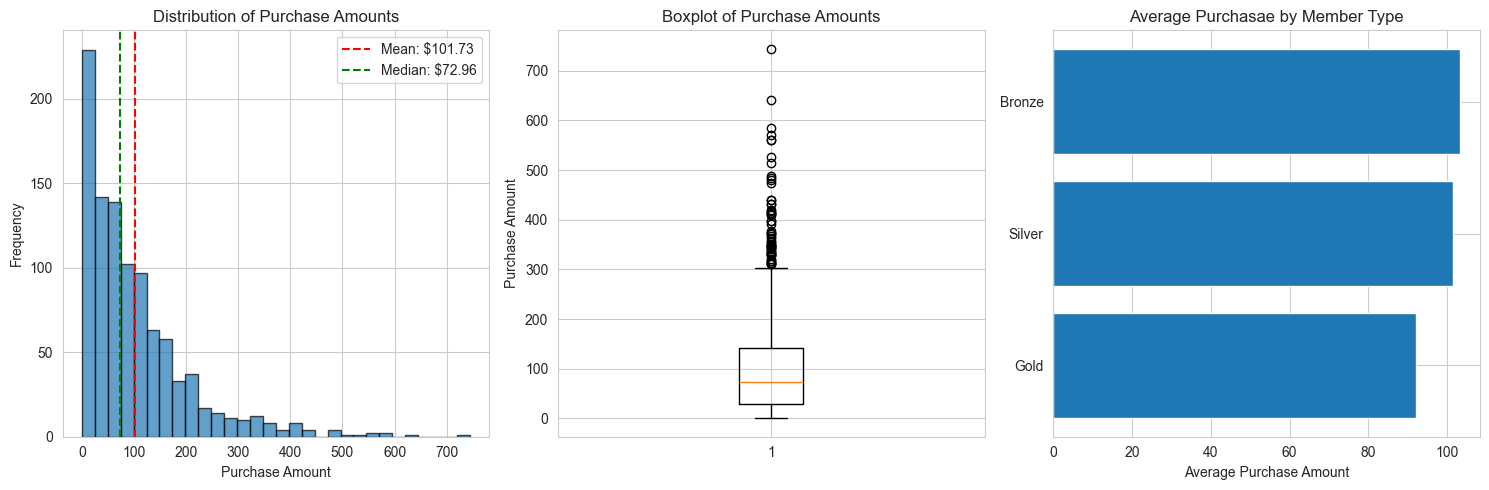

In [7]:
# 평균값, 중앙값, 최빈값 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 히스토그램
axes[0].hist(purchase_amounts, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(mean_value, color='red', linestyle='--', label=f'Mean: ${mean_value:.2f}')
axes[0].axvline(median_value, color='green', linestyle='--', label=f'Median: ${median_value:.2f}')
axes[0].set_xlabel('Purchase Amount')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Purchase Amounts')
axes[0].legend()

# 박스플롯
axes[1].boxplot(purchase_amounts)
axes[1].set_ylabel('Purchase Amount')
axes[1].set_title('Boxplot of Purchase Amounts')

# 회원 유형별 평균 구매액
member_means = customer_data.groupby('member_type')['purchase_amount'].mean().sort_values()
axes[2].barh(member_means.index, member_means.values)
axes[2].set_xlabel('Average Purchase Amount')
axes[2].set_title('Average Purchasae by Member Type')

plt.tight_layout()
plt.show()

In [8]:
# 이상치 탐지 (Boxplot)
customer_data = pd.read_csv("customer_data.csv")

# IQR 방법을 사용한 이상치 탐지
Q3 = customer_data['purchase_amount'].quantile(0.75)
Q1 = customer_data['purchase_amount'].quantile(0.25)
IQR = Q3 - Q1

# 이상치 경계를 설정한다
lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)

# 이상치 찾기
outliers = customer_data[
    (customer_data['purchase_amount'] < lower_bound)
    | (customer_data['purchase_amount'] > upper_bound)
]

print(f"=== 이상치 탐지 결과 ===")
print(f"Q1: ${Q1:.2f}")
print(f"Q3: ${Q3:.2f}")
print(f"IQR: ${IQR:.2f}")
print(f"하한 경계: ${lower_bound:.2f}")
print(f"상한 경계: ${upper_bound:.2f}")
print(f"이상치 개수: {len(outliers)} ({len(outliers)/len(customer_data)*100:.1f}%)")

=== 이상치 탐지 결과 ===
Q1: $28.36
Q3: $140.85
IQR: $112.50
하한 경계: $-140.39
상한 경계: $309.59
이상치 개수: 55 (5.5%)


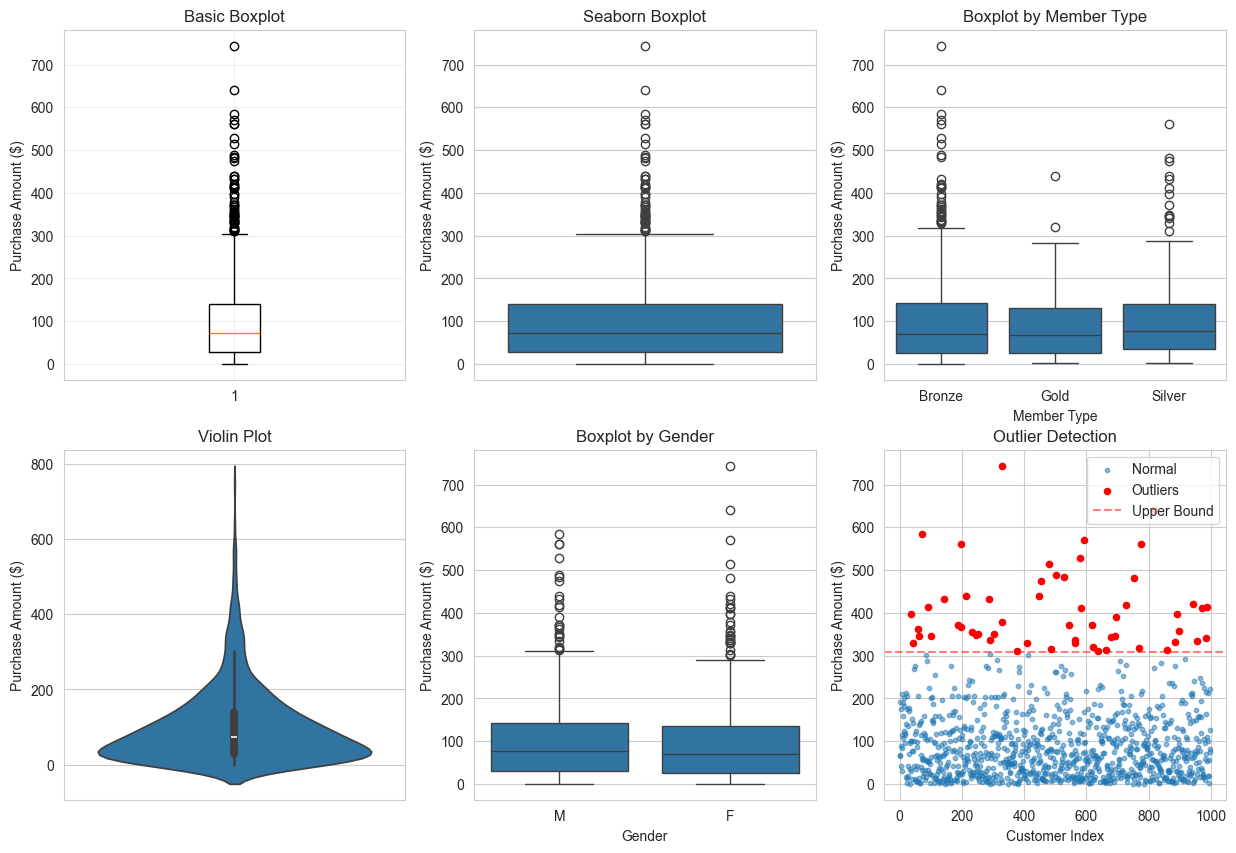

In [9]:
# 이상치 탐지 시각화
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. 기본 박스플롯
axes[0,0].boxplot(customer_data['purchase_amount'])
axes[0,0].set_ylabel('Purchase Amount ($)')
axes[0,0].set_title('Basic Boxplot')
axes[0,0].grid(True, alpha=0.3)

# 2. Seaborn 박스플롯
sns.boxplot(data=customer_data, y='purchase_amount', ax=axes[0,1])
axes[0,1].set_title('Seaborn Boxplot')
axes[0,1].set_ylabel('Purchase Amount ($)')

# 3. 회원 유형별 박스플롯
sns.boxplot(data=customer_data, x='member_type', y='purchase_amount', ax=axes[0,2])
axes[0,2].set_title('Boxplot by Member Type')
axes[0,2].set_xlabel('Member Type')
axes[0,2].set_ylabel('Purchase Amount ($)')

# 4. 바이올린 플롯 (분포 형태와 함께 표시)
sns.violinplot(data=customer_data, y='purchase_amount', ax=axes[1,0])
axes[1,0].set_title('Violin Plot')
axes[1,0].set_ylabel('Purchase Amount ($)')

# 5. 성별에 따른 박스플롯
sns.boxplot(data=customer_data, x='gender', y='purchase_amount', ax=axes[1,1])
axes[1,1].set_title('Boxplot by Gender')
axes[1,1].set_xlabel('Gender')
axes[1,1].set_ylabel('Purchase Amount ($)')

# 6. 이상치 표시된 산점도
axes[1,2].scatter(range(len(customer_data)), customer_data['purchase_amount'], alpha=0.5, s=10, label='Normal')
axes[1,2].scatter(outliers.index, outliers['purchase_amount'], color='red', s=20, label='Outliers')
axes[1,2].axhline(y=upper_bound, color='r', linestyle='--', alpha=0.5, label='Upper Bound')
axes[1,2].set_xlabel('Customer Index')
axes[1,2].set_ylabel('Purchase Amount ($)')
axes[1,2].set_title('Outlier Detection')
axes[1,2].legend()

In [ ]:
# 정규분포

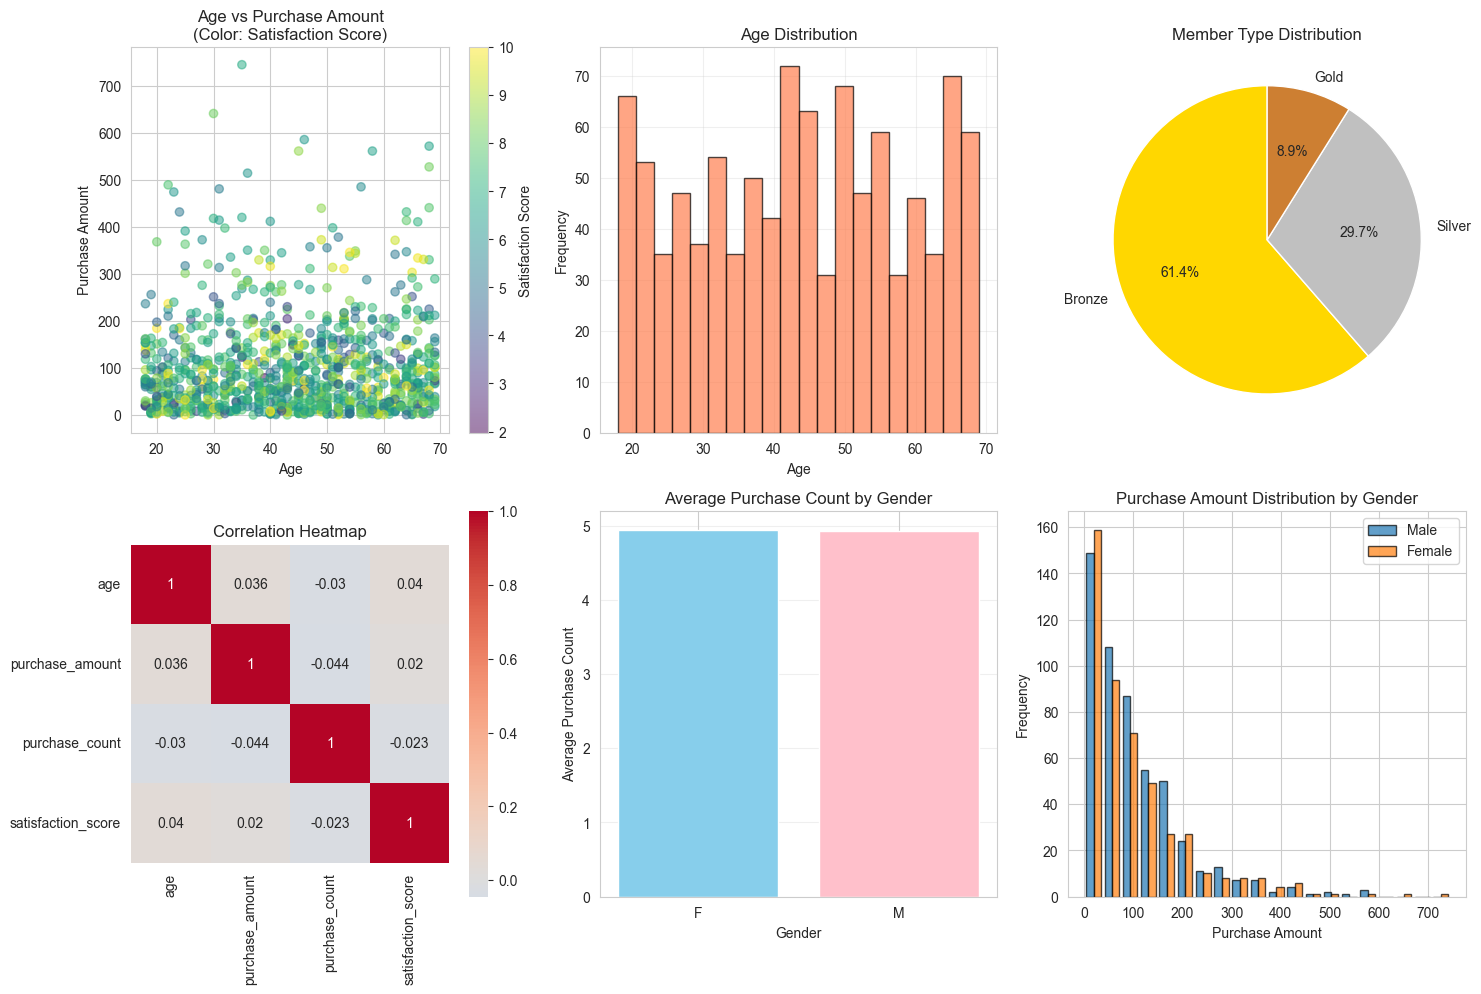

In [13]:
# 산점도, 히스토그램, 파이차트 만들기
fig, axes = plt.subplots(2,3, figsize=(15,10))

# 1. 산점도 - 나이와 구매 금액 관계
axes[0,0].scatter(customer_data['age'], customer_data['purchase_amount'], alpha=0.5, c=customer_data['satisfaction_score'], cmap='viridis')
axes[0,0].set_xlabel('Age')
axes[0,0].set_ylabel('Purchase Amount')
axes[0,0].set_title('Age vs Purchase Amount\n(Color: Satisfaction Score)')
cbar = plt.colorbar(axes[0,0].collections[0], ax=axes[0,0])
cbar.set_label('Satisfaction Score')

# 2. 히스토그램 - 나이 분포
axes[0,1].hist(customer_data['age'], bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[0,1].set_xlabel('Age')
axes[0,1].set_ylabel('Frequency')
axes[0,1].set_title('Age Distribution')
axes[0,1].grid(True, alpha=0.3)

# 3. 파이차트 - 회원 유형 분포
member_counts = customer_data['member_type'].value_counts()
colors = ['gold', 'silver', '#CD7F32']      # gold, silver, bronze
axes[0,2].pie(member_counts.values, labels=member_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
axes[0,2].set_title('Member Type Distribution')

# 4. 상관관계 히트맵을 위한 데이터
correlation_data = customer_data[['age', 'purchase_amount', 'purchase_count', 'satisfaction_score']].corr()
sns.heatmap(correlation_data, annot=True, cmap='coolwarm', center=0, square=True, ax=axes[1,0])
axes[1,0].set_title('Correlation Heatmap')

# 5. 성별에 따른 구매 횟수 막대 그래프
gender_purchase = customer_data.groupby('gender')['purchase_count'].mean()
axes[1,1].bar(gender_purchase.index, gender_purchase.values, color=['skyblue', 'pink'])
axes[1,1].set_xlabel('Gender')
axes[1,1].set_ylabel('Average Purchase Count')
axes[1,1].set_title('Average Purchase Count by Gender')
axes[1,1].grid(True, alpha=0.3, axis='y')

# 6. 누적 히스토그램 - 구매 금액 분포 (성별 구분)
males = customer_data[customer_data['gender'] == 'M']['purchase_amount']
females = customer_data[customer_data['gender'] == 'F']['purchase_amount']
axes[1,2].hist([males, females], bins=20, label=['Male', 'Female'], alpha=0.7, edgecolor='black')
axes[1,2].set_xlabel('Purchase Amount')
axes[1,2].set_ylabel('Frequency')
axes[1,2].set_title('Purchase Amount Distribution by Gender')
axes[1,2].legend()

plt.tight_layout()
plt.show()